In [ ]:
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("ДОСТУПНЫЕ ФАЙЛЫ")
print("="*50)
print("Загрузите файлы, которые у вас есть:")
print("  - 07_marketing_leads.csv (обязательно)")
print("  - 02_crm_transactions.csv (если есть)")
print("  - 01_crm_companies.csv (если есть)")
print("="*50)

uploaded = files.upload()

# Проверяем, какие файлы загружены
print("\n ЗАГРУЖЕННЫЕ ФАЙЛЫ:")
for filename in uploaded.keys():
    print(f"  - {filename}")

ДОСТУПНЫЕ ФАЙЛЫ
Загрузите файлы, которые у вас есть:
  - 07_marketing_leads.csv (обязательно)
  - 02_crm_transactions.csv (если есть)
  - 01_crm_companies.csv (если есть)


Saving 01_crm_companies.csv to 01_crm_companies (2).csv
Saving 01_crm_companies.xlsx to 01_crm_companies (2).xlsx
Saving 02_crm_transactions.csv to 02_crm_transactions (2).csv
Saving 02_crm_transactions.xlsx to 02_crm_transactions (2).xlsx
Saving 03_lms_events.csv to 03_lms_events (2).csv
Saving 03_lms_events.xlsx to 03_lms_events (2).xlsx
Saving 04_lms_courses.csv to 04_lms_courses (2).csv
Saving 04_lms_courses.xlsx to 04_lms_courses (2).xlsx
Saving 05_finance_payments.csv to 05_finance_payments (2).csv
Saving 05_finance_payments.xlsx to 05_finance_payments (2).xlsx
Saving 06_support_tickets.csv to 06_support_tickets (2).csv
Saving 06_support_tickets.xlsx to 06_support_tickets (2).xlsx
Saving 07_marketing_leads.csv to 07_marketing_leads (2).csv
Saving 07_marketing_leads.xlsx to 07_marketing_leads (2).xlsx
Saving 08_hr_employees.csv to 08_hr_employees (2).csv
Saving 08_hr_employees.xlsx to 08_hr_employees (2).xlsx
Saving 09_products.csv to 09_products (2).csv
Saving 09_products.xlsx to

In [ ]:
# Загружаем leads
leads = pd.read_csv('07_marketing_leads.csv')

print("ИСХОДНЫЕ ДАННЫЕ:")
print(f"Всего лидов: {len(leads)}")
print(f"Колонки: {leads.columns.tolist()}")
print(f"\nПервые строки:")
print(leads.head())

# Преобразуем дату
leads['lead_date'] = pd.to_datetime(leads['lead_date'], errors='coerce')

# Создаем колонку месяц-год
leads['month'] = leads['lead_date'].dt.to_period('M').astype(str)

# Агрегируем по каналам и месяцам
marketing_history = leads.groupby(['source', 'month']).size().reset_index(name='leads_count')

# Переименовываем колонки
marketing_history.columns = ['channel', 'month', 'leads_count']

# Преобразуем month обратно в datetime для удобства
marketing_history['month'] = pd.to_datetime(marketing_history['month'])

# Сортируем
marketing_history = marketing_history.sort_values(['channel', 'month'])

print("\n" + "="*50)
print("СОЗДАН ФАЙЛ MARKETING_HISTORY")
print("="*50)
print(f"Строк: {len(marketing_history)}")
print(f"Каналы: {marketing_history['channel'].unique().tolist()}")
print(f"Период: {marketing_history['month'].min().date()} до {marketing_history['month'].max().date()}")
print(f"\nПервые строки:")
print(marketing_history.head(10))

# Сохраняем созданный файл
marketing_history.to_csv('12_marketing_history.csv', index=False)
print("\n Файл '12_marketing_history.csv' создан и сохранен!")

ИСХОДНЫЕ ДАННЫЕ:
Всего лидов: 100
Колонки: ['lead_id', 'company_name', 'contact_person', 'source', 'campaign', 'lead_date', 'cost', 'status']

Первые строки:
  lead_id        company_name  contact_person      source         campaign  \
0    L001       ООО "Ромашка"     Иванов И.И.     website   brand_campaign   
1    L002    АО "ТехноСервис"     Петров П.П.  conference     edtech_forum   
2    L003          ИП Сидоров    Сидоров С.С.    referral   partner_ivanov   
3    L004  ООО "Айти-Решения"   Николаев Н.Н.     website         seo_2024   
4    L005  ООО "Торговый Дом"  Григорьев Г.Г.       email  july_newsletter   

    lead_date   cost     status  
0  2024-06-10      0  converted  
1  2024-06-15  35000  converted  
2  2024-06-20      0  converted  
3  2024-07-05      0  converted  
4  2024-07-18   5000  converted  

СОЗДАН ФАЙЛ MARKETING_HISTORY
Строк: 53
Каналы: ['conference', 'email', 'linkedin', 'referral', 'website']
Период: 2024-04-01 до 2025-03-01

Первые строки:
      channe


ПРОВЕРКА ПОЛНОТЫ ДАННЫХ
Количество лидов по месяцам и каналам:
channel     conference  email  linkedin  referral  website
month                                                     
2024-04-01         2.0    1.0       1.0       1.0      4.0
2024-05-01         3.0    3.0       2.0       2.0      2.0
2024-06-01         2.0    1.0       2.0       2.0      5.0
2024-07-01         1.0    3.0       2.0       1.0      4.0
2024-08-01         3.0    1.0       3.0       1.0      4.0
2024-09-01         2.0    3.0       1.0       2.0      5.0
2024-10-01         2.0    2.0       2.0       0.0      2.0
2024-11-01         1.0    0.0       1.0       1.0      2.0
2024-12-01         1.0    1.0       1.0       1.0      1.0
2025-01-01         1.0    0.0       0.0       1.0      1.0
2025-02-01         1.0    1.0       1.0       0.0      2.0
2025-03-01         0.0    0.0       1.0       1.0      3.0


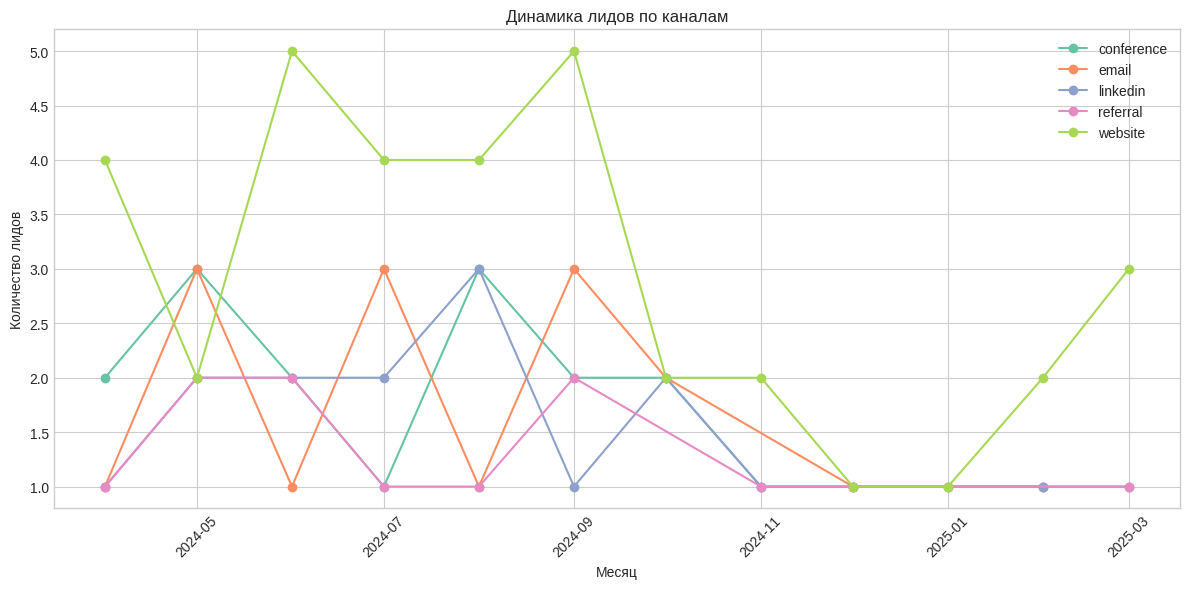

In [ ]:
# Проверяем, есть ли данные за все месяцы для каждого канала
print("\n" + "="*50)
print("ПРОВЕРКА ПОЛНОТЫ ДАННЫХ")
print("="*50)

# Сводная таблица
pivot_table = marketing_history.pivot_table(
    index='month',
    columns='channel',
    values='leads_count',
    fill_value=0
)

print("Количество лидов по месяцам и каналам:")
print(pivot_table)

# Визуализируем
plt.figure(figsize=(12, 6))
for channel in marketing_history['channel'].unique():
    channel_data = marketing_history[marketing_history['channel'] == channel]
    plt.plot(channel_data['month'], channel_data['leads_count'], marker='o', label=channel)

plt.xlabel('Месяц')
plt.ylabel('Количество лидов')
plt.title('Динамика лидов по каналам')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
try:
    transactions = pd.read_csv('02_crm_transactions.csv')
    print(f"Загружены транзакции: {len(transactions)} строк")
except:
    transactions = None
    print("Файл 02_crm_transactions.csv не найден")

try:
    companies = pd.read_csv('01_crm_companies.csv')
    print(f"Загружены компании: {len(companies)} строк")
except:
    companies = None
    print("Файл 01_crm_companies.csv не найден")

Загружены транзакции: 42 строк
Загружены компании: 40 строк



УПРОЩЕННЫЙ АНАЛИЗ (только на основе лидов)

 ВИТРИНА (упрощенная):
            leads_count  total_cost  converted_count  conversion_rate  avg_ltv
source                                                                        
conference           19      665000               13             0.68    50000
email                16       80000               12             0.75    50000
linkedin             17      255000               11             0.65    50000
referral             13           0                7             0.54    50000
website              35           0               25             0.71    50000

ПРОГНОЗ НА АПРЕЛЬ 2025
     Канал  Прогноз лидов  Конверсия  Прогноз продаж  Выручка, млн руб
conference            1.0       0.68             1.0              0.03
     email            1.0       0.75             1.0              0.05
  linkedin            1.0       0.65             1.0              0.03
  referral            1.0       0.54             1.0              0.03


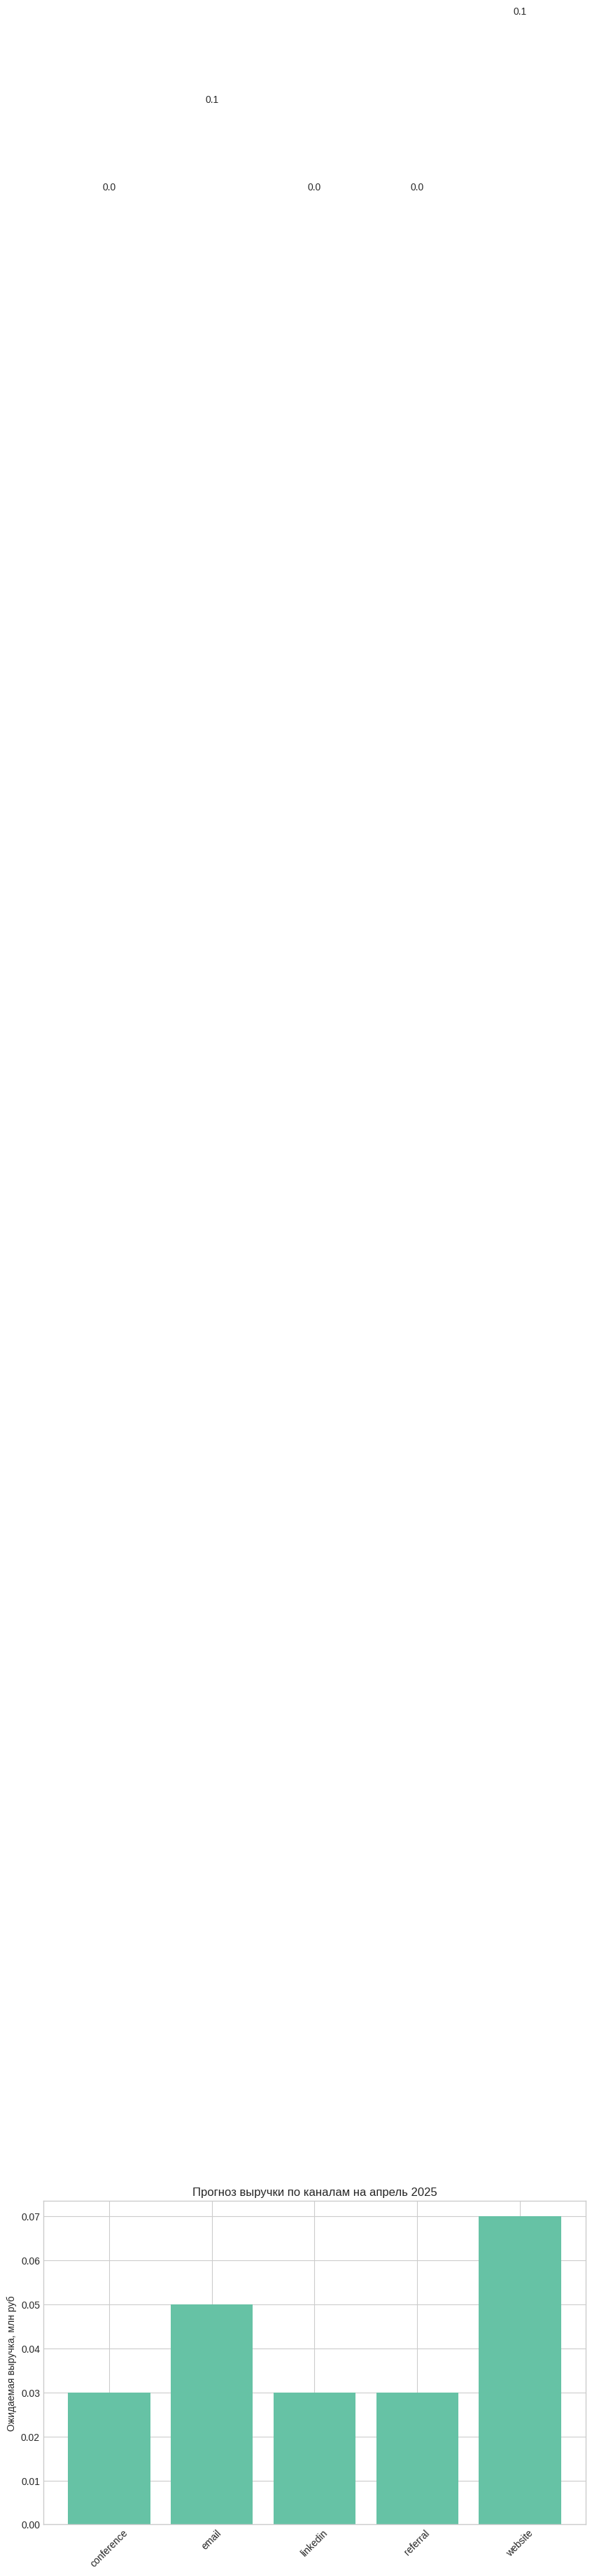

In [ ]:
print("\n" + "="*50)
print("УПРОЩЕННЫЙ АНАЛИЗ (только на основе лидов)")
print("="*50)

# Создаем базовую витрину только из лидов
channel_stats_simple = leads.groupby('source').agg({
    'lead_id': 'count',
    'cost': 'sum'
}).rename(columns={'lead_id': 'leads_count', 'cost': 'total_cost'})

# Добавляем конверсию из статусов
if 'status' in leads.columns:
    converted = leads[leads['status'] == 'converted'].groupby('source').size()
    channel_stats_simple['converted_count'] = converted
    channel_stats_simple['converted_count'] = channel_stats_simple['converted_count'].fillna(0)
    channel_stats_simple['conversion_rate'] = channel_stats_simple['converted_count'] / channel_stats_simple['leads_count']
else:
    # Если нет статуса, используем примерную конверсию 10%
    channel_stats_simple['conversion_rate'] = 0.1

# Примерный LTV (если нет реальных данных)
channel_stats_simple['avg_ltv'] = 50000  # 50 000 руб примерный LTV

print("\n ВИТРИНА (упрощенная):")
print(channel_stats_simple.round(2))

# Прогноз
print("\n" + "="*50)
print("ПРОГНОЗ НА АПРЕЛЬ 2025")
print("="*50)

forecasts = []
for channel in marketing_history['channel'].unique():
    channel_data = marketing_history[marketing_history['channel'] == channel].sort_values('month')

    if len(channel_data) >= 3:
        # Используем последние 3 месяца для прогноза
        recent = channel_data['leads_count'].tail(3).mean()
        forecast = recent
        std = recent * 0.3
    else:
        forecast = channel_stats_simple.loc[channel, 'leads_count']
        std = forecast * 0.5

    # Получаем конверсию для канала
    if channel in channel_stats_simple.index:
        conv_rate = channel_stats_simple.loc[channel, 'conversion_rate']
        ltv = channel_stats_simple.loc[channel, 'avg_ltv']
    else:
        conv_rate = 0.1
        ltv = 50000

    expected_sales = forecast * conv_rate
    expected_revenue = expected_sales * ltv / 1_000_000

    forecasts.append({
        'Канал': channel,
        'Прогноз лидов': round(forecast, 0),
        'Конверсия': round(conv_rate, 2),
        'Прогноз продаж': round(expected_sales, 0),
        'Выручка, млн руб': round(expected_revenue, 2)
    })

forecast_df = pd.DataFrame(forecasts)
print(forecast_df.to_string(index=False))

# Визуализация
plt.figure(figsize=(10, 6))
plt.bar(forecast_df['Канал'], forecast_df['Выручка, млн руб'])
plt.ylabel('Ожидаемая выручка, млн руб')
plt.title('Прогноз выручки по каналам на апрель 2025')
plt.xticks(rotation=45)
for i, row in forecast_df.iterrows():
    plt.text(i, row['Выручка, млн руб'] + 0.5, f"{row['Выручка, млн руб']:.1f}",
             ha='center', va='bottom')
plt.tight_layout()
plt.show()

In [ ]:
print("="*60)
print("ПРОВЕРКА СТРУКТУРЫ ДАННЫХ")
print("="*60)

# Проверяем транзакции
print("\n Файл транзакций (02_crm_transactions.csv):")
print(f"Колонки: {transactions.columns.tolist()}")
print(f"Первые 2 строки:")
print(transactions.head(2))

# Проверяем компании
print("\n Файл компаний (01_crm_companies.csv):")
print(f"Колонки: {companies.columns.tolist()}")
print(f"Первые 2 строки:")
print(companies.head(2))

# Проверяем лиды
print("\n Файл лидов (07_marketing_leads.csv):")
print(f"Колонки: {leads.columns.tolist()}")
print(f"Первые 2 строки:")
print(leads.head(2))

# Проверяем marketing_history (созданный)
print("\n Файл marketing_history (созданный):")
print(f"Колонки: {marketing_history.columns.tolist()}")
print(f"Первые 2 строки:")
print(marketing_history.head(2))

ПРОВЕРКА СТРУКТУРЫ ДАННЫХ

 Файл транзакций (02_crm_transactions.csv):
Колонки: ['transaction_id', 'company_id', 'transaction_date', 'product_id', 'quantity', 'unit_price', 'total_amount', 'transaction_stage', 'manager', 'probability']
Первые 2 строки:
  transaction_id  company_id transaction_date product_id  quantity  \
0           D001        1001       2025-01-15       P001        10   
1           D002        1001       2025-02-10       P002         5   

   unit_price  total_amount transaction_stage manager  probability  
0       15000        150000        closed_won  Иванов          100  
1       40000        200000        closed_won  Иванов          100  

 Файл компаний (01_crm_companies.csv):
Колонки: ['company_id', 'company_name', 'inn', 'industry', 'region', 'employee_count', 'created_date', 'status']
Первые 2 строки:
   company_id      company_name         inn industry region  employee_count  \
0        1001     ООО "Ромашка"  7701123456   Retail    ЦФО             120   
1

In [ ]:
print("\n" + "="*60)
print("="*60)

# Успешные транзакции
successful_trans = transactions[transactions['transaction_stage'] == 'closed_won'].copy()
print(f" Успешных сделок: {len(successful_trans)}")

# Выручка по компаниям (используем total_amount)
company_revenue = successful_trans.groupby('company_id').agg({
    'total_amount': ['sum', 'count', 'mean']
}).round(2)
company_revenue.columns = ['total_revenue', 'purchase_count', 'avg_check']
company_revenue = company_revenue.reset_index()
print(f" Компаний с покупками: {len(company_revenue)}")
print(f"   Общая выручка: {company_revenue['total_revenue'].sum():,.0f} руб")

# Подготовка лидов
leads_clean = leads.copy()

# Преобразуем дату
leads_clean['lead_date'] = pd.to_datetime(leads_clean['lead_date'])
leads_clean['month'] = leads_clean['lead_date'].dt.to_period('M').astype(str)

# Создаем is_converted
leads_clean['is_converted'] = (leads_clean['status'] == 'converted').astype(int)
print(f" Конверсия в данных: {leads_clean['is_converted'].mean():.2%}")

# Связываем лиды с компаниями по названию
company_name_to_id = companies[['company_id', 'company_name']].drop_duplicates()
leads_with_id = leads_clean.merge(company_name_to_id, on='company_name', how='left')
matched_ratio = leads_with_id['company_id'].notna().mean()
print(f" Связано лидов с company_id: {matched_ratio:.1%}")

# Добавляем выручку
leads_with_revenue = leads_with_id.merge(company_revenue, on='company_id', how='left')
leads_with_revenue['total_revenue'] = leads_with_revenue['total_revenue'].fillna(0)

# Определяем первый лид для каждой компании
leads_with_revenue = leads_with_revenue.sort_values('lead_date')
first_lead = leads_with_revenue.groupby('company_id').first().reset_index()
print(f" Уникальных компаний (первые лиды): {len(first_lead)}")

# Агрегация по каналам
channel_stats = first_lead.groupby('source').agg({
    'lead_id': 'count',  # количество компаний
    'is_converted': 'sum',  # конвертированные компании
    'total_revenue': 'sum',  # общая выручка
    'cost': 'sum'  # общие затраты
}).rename(columns={
    'lead_id': 'leads_count',
    'is_converted': 'converted_count',
    'total_revenue': 'total_revenue',
    'cost': 'total_cost'
})

# Расчет метрик
channel_stats['conversion_rate'] = channel_stats['converted_count'] / channel_stats['leads_count']
channel_stats['avg_ltv'] = channel_stats['total_revenue'] / channel_stats['converted_count'].replace(0, np.nan)
channel_stats['cac'] = channel_stats['total_cost'] / channel_stats['converted_count'].replace(0, np.nan)
channel_stats['roi'] = (channel_stats['total_revenue'] - channel_stats['total_cost']) / channel_stats['total_cost'].replace(0, np.nan)

# Заполняем NaN
channel_stats = channel_stats.fillna(0)

print("\n ПОЛНАЯ ВИТРИНА MARKETING_CHANNEL_EFFECTIVENESS:")
print("="*80)
print(channel_stats.round(2))

# Сохраняем
channel_stats.to_csv('marketing_channel_effectiveness.csv')
print("\n Витрина сохранена в 'marketing_channel_effectiveness.csv'")


 Успешных сделок: 34
 Компаний с покупками: 31
   Общая выручка: 5,698,000 руб
 Конверсия в данных: 68.00%
 Связано лидов с company_id: 32.0%
 Уникальных компаний (первые лиды): 17

 ПОЛНАЯ ВИТРИНА MARKETING_CHANNEL_EFFECTIVENESS:
            leads_count  converted_count  total_revenue  total_cost  \
source                                                                
conference            2                2       735000.0       70000   
email                 3                1       345000.0       15000   
linkedin              2                2       425000.0       30000   
referral              1                0        60000.0           0   
website               9                8      1157000.0           0   

            conversion_rate   avg_ltv      cac    roi  
source                                                 
conference             1.00  367500.0  35000.0   9.50  
email                  0.33  345000.0  15000.0  22.00  
linkedin               1.00  212500.0  15000.0


ШАГ 7: ПРОГНОЗ ЛИДОВ НА АПРЕЛЬ 2025

ПРОГНОЗ ЛИДОВ НА АПРЕЛЬ 2025:
   channel  forecast_leads  forecast_std  forecast_lower  forecast_upper
conference             1.0           1.0             0.0             2.0
     email             1.0           1.0             0.0             3.0
  linkedin             1.0           1.0             0.0             2.0
  referral             1.0           0.0             0.0             2.0
   website             1.0           1.0             0.0             4.0


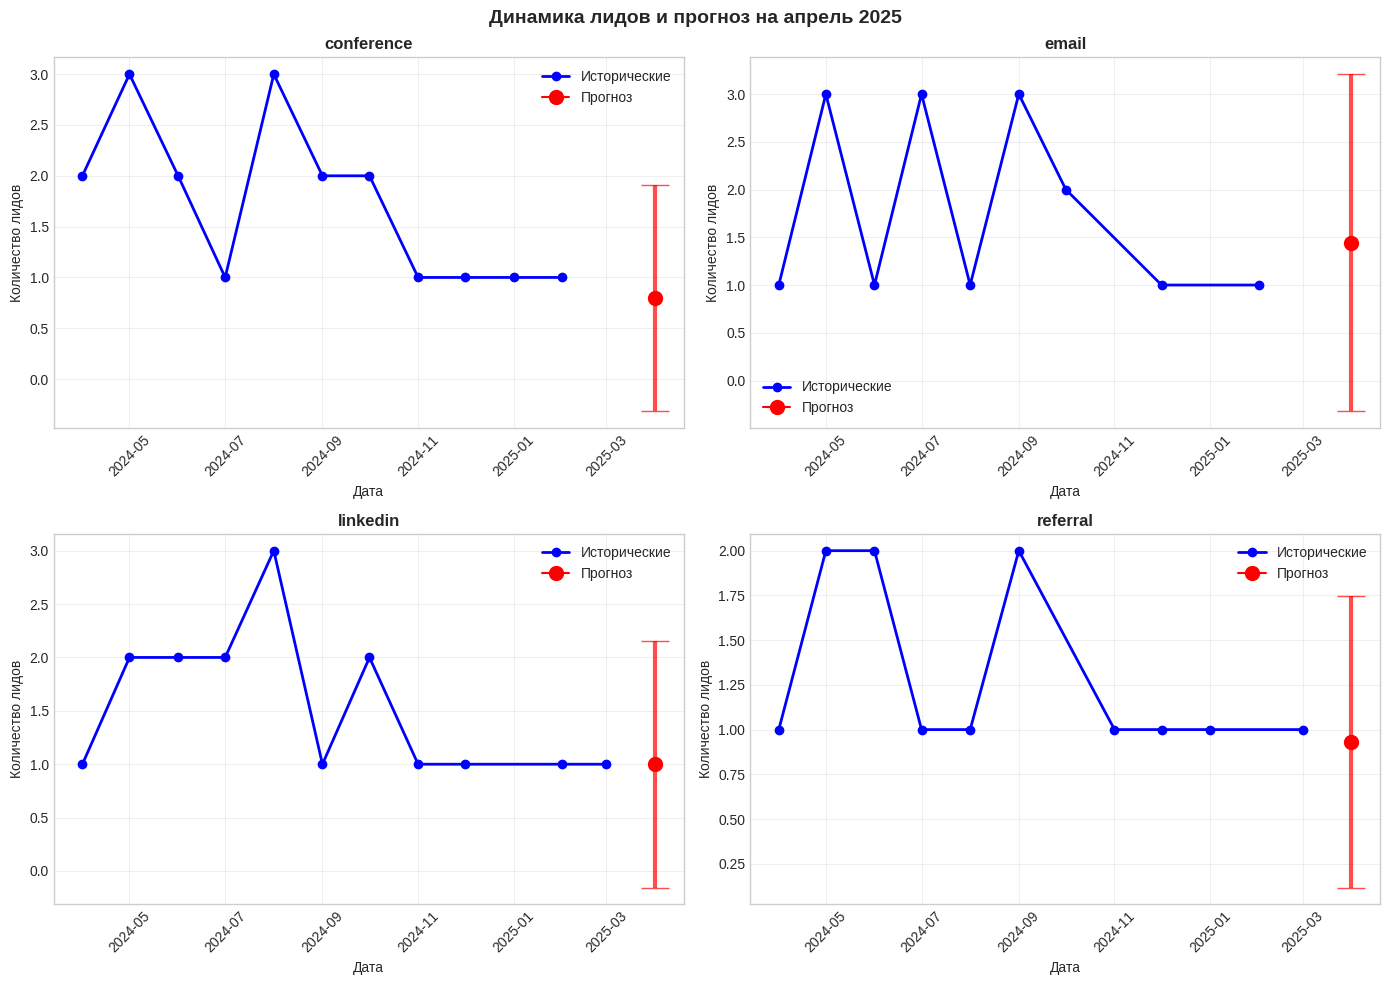

In [ ]:
print("\n" + "="*60)
print("ШАГ 7: ПРОГНОЗ ЛИДОВ НА АПРЕЛЬ 2025")
print("="*60)

# Создаем marketing_history из лидов (если еще не создан)
if 'marketing_history' not in locals() or marketing_history is None:
    print("Создаем историю маркетинга из данных о лидах...")
    marketing_history = leads_clean.groupby(['source', 'month']).size().reset_index(name='leads_count')
    marketing_history.columns = ['channel', 'month', 'leads_count']
    marketing_history['month'] = pd.to_datetime(marketing_history['month'])
    marketing_history = marketing_history.sort_values(['channel', 'month'])
    print(f" Создано {len(marketing_history)} записей")

# Функция для прогнозирования
def forecast_channel_simple(channel_data, channel_name):
    """Простой прогноз для канала"""
    if len(channel_data) >= 4:
        # Линейная регрессия
        from scipy import stats
        x = np.arange(len(channel_data))
        y = channel_data['leads_count'].values
        slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

        next_x = len(channel_data)
        forecast = intercept + slope * next_x
        forecast = max(0, forecast)

        # Оценка ошибки
        residuals = y - (intercept + slope * x)
        std_forecast = np.std(residuals) if len(residuals) > 1 else forecast * 0.3

    elif len(channel_data) >= 3:
        # Скользящее среднее за 3 месяца
        recent = channel_data['leads_count'].tail(3).values
        forecast = np.mean(recent)
        std_forecast = np.std(recent) * 1.2
    else:
        # Мало данных - используем среднее по каналу из витрины
        forecast = channel_stats.loc[channel_name, 'leads_count']
        std_forecast = forecast * 0.5

    return forecast, std_forecast

# Прогноз для всех каналов
forecast_results = []

for channel in channel_stats.index:
    channel_data = marketing_history[marketing_history['channel'] == channel].sort_values('month')

    if len(channel_data) == 0:
        print(f" Нет исторических данных для канала {channel}, используем среднее")
        forecast = channel_stats.loc[channel, 'leads_count']
        std_forecast = forecast * 0.5
    else:
        forecast, std_forecast = forecast_channel_simple(channel_data, channel)

    forecast_results.append({
        'channel': channel,
        'forecast_leads': forecast,
        'forecast_std': std_forecast,
        'forecast_lower': max(0, forecast - 1.96 * std_forecast),
        'forecast_upper': forecast + 1.96 * std_forecast
    })

forecast_df = pd.DataFrame(forecast_results)
print("\nПРОГНОЗ ЛИДОВ НА АПРЕЛЬ 2025:")
print(forecast_df.round(0).to_string(index=False))

# Визуализация динамики
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, channel in enumerate(channel_stats.index[:4]):  # Первые 4 канала
    ax = axes[idx]
    channel_data = marketing_history[marketing_history['channel'] == channel].sort_values('month')

    # Исторические данные
    ax.plot(channel_data['month'], channel_data['leads_count'], 'b-o', label='Исторические', linewidth=2, markersize=6)

    # Прогноз
    forecast_row = forecast_df[forecast_df['channel'] == channel].iloc[0]
    next_month = pd.Timestamp('2025-04-01')

    ax.plot(next_month, forecast_row['forecast_leads'], 'r-o', markersize=10, label='Прогноз')
    ax.errorbar(next_month, forecast_row['forecast_leads'],
                yerr=1.96*forecast_row['forecast_std'],
                capsize=10, color='red', alpha=0.7, elinewidth=3)

    ax.set_title(f'{channel}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Дата')
    ax.set_ylabel('Количество лидов')
    ax.legend()
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3)

plt.suptitle('Динамика лидов и прогноз на апрель 2025', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
print("\n" + "="*60)
print("ПРОГНОЗ ПРОДАЖ И ВЫРУЧКИ")
print("="*60)

# Объединяем прогнозы с параметрами каналов
sales_forecast = forecast_df.merge(
    channel_stats[['conversion_rate', 'avg_ltv', 'total_cost', 'total_revenue']],
    left_on='channel',
    right_index=True
)

# Расчет продаж с учетом двух уровней неопределенности
sales_forecast['mu_sales'] = sales_forecast['forecast_leads'] * sales_forecast['conversion_rate']
sales_forecast['var_sales'] = (
    (sales_forecast['forecast_std']**2) * (sales_forecast['conversion_rate']**2) +
    sales_forecast['forecast_leads'] * sales_forecast['conversion_rate'] * (1 - sales_forecast['conversion_rate'])
)
sales_forecast['std_sales'] = np.sqrt(sales_forecast['var_sales'])

# Доверительные интервалы для продаж
sales_forecast['sales_lower'] = np.maximum(0, sales_forecast['mu_sales'] - 1.96 * sales_forecast['std_sales'])
sales_forecast['sales_upper'] = sales_forecast['mu_sales'] + 1.96 * sales_forecast['std_sales']

# Прогноз выручки
sales_forecast['expected_revenue'] = sales_forecast['mu_sales'] * sales_forecast['avg_ltv']
sales_forecast['revenue_lower'] = sales_forecast['sales_lower'] * sales_forecast['avg_ltv']
sales_forecast['revenue_upper'] = sales_forecast['sales_upper'] * sales_forecast['avg_ltv']

# Переводим в миллионы
sales_forecast['expected_revenue_m'] = sales_forecast['expected_revenue'] / 1_000_000
sales_forecast['revenue_lower_m'] = sales_forecast['revenue_lower'] / 1_000_000
sales_forecast['revenue_upper_m'] = sales_forecast['revenue_upper'] / 1_000_000

print("\n ПРОГНОЗ ПРОДАЖ И ВЫРУЧКИ:")
print("="*100)
display_cols = ['channel', 'forecast_leads', 'conversion_rate', 'mu_sales',
                'sales_lower', 'sales_upper', 'expected_revenue_m', 'revenue_lower_m', 'revenue_upper_m']
print(sales_forecast[display_cols].round(2).to_string(index=False))


ПРОГНОЗ ПРОДАЖ И ВЫРУЧКИ

 ПРОГНОЗ ПРОДАЖ И ВЫРУЧКИ:
   channel  forecast_leads  conversion_rate  mu_sales  sales_lower  sales_upper  expected_revenue_m  revenue_lower_m  revenue_upper_m
conference            0.80             1.00      0.80          0.0         1.91                0.29              0.0             0.70
     email            1.44             0.33      0.48          0.0         1.74                0.17              0.0             0.60
  linkedin            1.00             1.00      1.00          0.0         2.15                0.21              0.0             0.46
  referral            0.93             0.00      0.00          0.0         0.00                0.00              0.0             0.00
   website            1.48             0.89      1.32          0.0         3.47                0.19              0.0             0.50



ИТОГОВЫЙ ПРОГНОЗ НА АПРЕЛЬ 2025

 ИТОГОВАЯ ТАБЛИЦА ПРОГНОЗА:
     Канал  Прогноз лидов Конверсия  Ожидаемые продажи  Выручка, млн руб  Нижняя граница  Верхняя граница  Затраты, руб  Выручка_историческая
conference              1    100.0%                  1              0.29             0.0             0.70         70000                  0.74
     email              1     33.3%                  0              0.17             0.0             0.60         15000                  0.34
  linkedin              1    100.0%                  1              0.21             0.0             0.46         30000                  0.42
  referral              1      0.0%                  0              0.00             0.0             0.00             0                  0.06
   website              1     88.9%                  1              0.19             0.0             0.50             0                  1.16

СВОДНЫЕ ПОКАЗАТЕЛИ ПО ВСЕМ КАНАЛАМ:
 Всего лидов: 5
 Всего продаж: 3
 Ожидаемая выруч

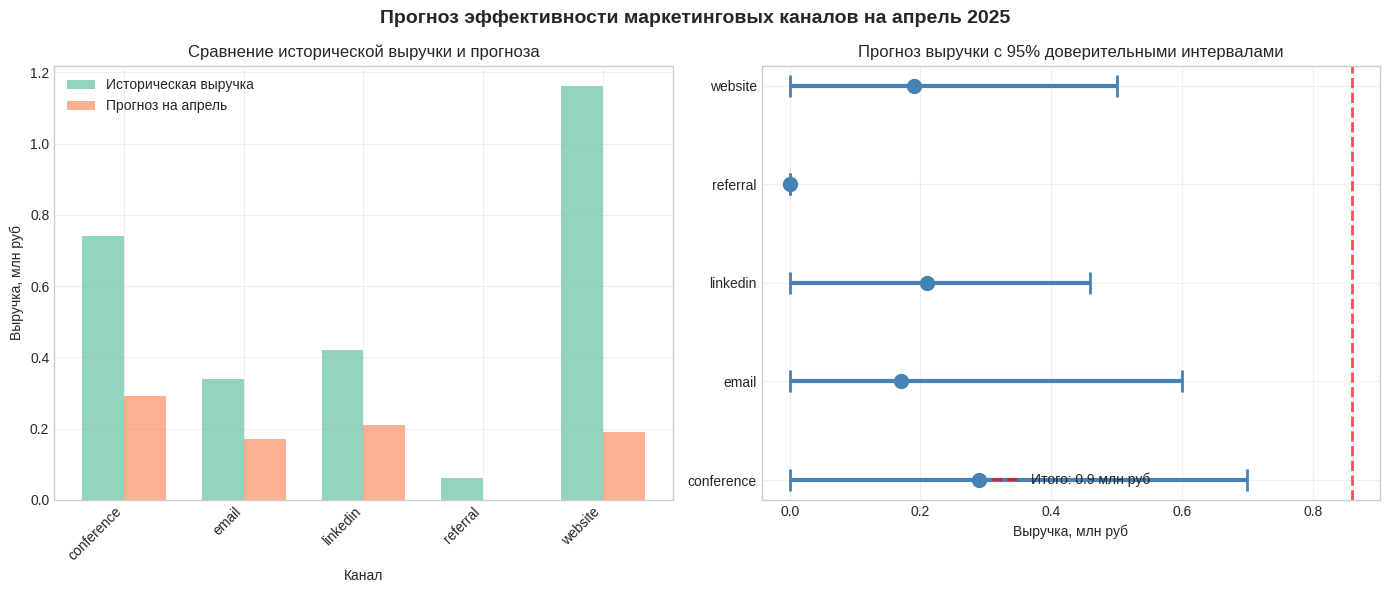


 График сохранен как 'final_forecast.png'


In [ ]:
print("\n" + "="*60)
print("ИТОГОВЫЙ ПРОГНОЗ НА АПРЕЛЬ 2025")
print("="*60)

# Формируем итоговую таблицу
final_table = sales_forecast[[
    'channel', 'forecast_leads', 'conversion_rate', 'mu_sales',
    'expected_revenue_m', 'revenue_lower_m', 'revenue_upper_m', 'total_cost', 'total_revenue'
]].copy()

final_table.columns = [
    'Канал', 'Прогноз лидов', 'Конверсия', 'Ожидаемые продажи',
    'Выручка, млн руб', 'Нижняя граница', 'Верхняя граница', 'Затраты, руб', 'Выручка_историческая'
]

# Округляем
final_table['Прогноз лидов'] = final_table['Прогноз лидов'].round(0).astype(int)
final_table['Ожидаемые продажи'] = final_table['Ожидаемые продажи'].round(0).astype(int)
final_table['Конверсия'] = (final_table['Конверсия'] * 100).round(1).astype(str) + '%'
final_table['Выручка, млн руб'] = final_table['Выручка, млн руб'].round(2)
final_table['Нижняя граница'] = final_table['Нижняя граница'].round(2)
final_table['Верхняя граница'] = final_table['Верхняя граница'].round(2)
final_table['Затраты, руб'] = final_table['Затраты, руб'].round(0).astype(int)
final_table['Выручка_историческая'] = (final_table['Выручка_историческая'] / 1_000_000).round(2)

print("\n ИТОГОВАЯ ТАБЛИЦА ПРОГНОЗА:")
print("="*110)
print(final_table.to_string(index=False))

# Сводные показатели
print("\n" + "="*60)
print("СВОДНЫЕ ПОКАЗАТЕЛИ ПО ВСЕМ КАНАЛАМ:")
print("="*60)
print(f" Всего лидов: {final_table['Прогноз лидов'].sum():.0f}")
print(f" Всего продаж: {final_table['Ожидаемые продажи'].sum():.0f}")
print(f" Ожидаемая выручка: {final_table['Выручка, млн руб'].sum():.2f} млн руб")
print(f" Нижняя граница (95%): {final_table['Нижняя граница'].sum():.2f} млн руб")
print(f" Верхняя граница (95%): {final_table['Верхняя граница'].sum():.2f} млн руб")
print(f" Общие затраты: {final_table['Затраты, руб'].sum():,.0f} руб")
print(f" Историческая выручка: {final_table['Выручка_историческая'].sum():.2f} млн руб")

# Визуализация
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# График 1: Сравнение прогноза с историческими данными
x = np.arange(len(final_table))
width = 0.35

bars1 = ax1.bar(x - width/2, final_table['Выручка_историческая'], width, label='Историческая выручка', alpha=0.7)
bars2 = ax1.bar(x + width/2, final_table['Выручка, млн руб'], width, label='Прогноз на апрель', alpha=0.7)

ax1.set_xlabel('Канал')
ax1.set_ylabel('Выручка, млн руб')
ax1.set_title('Сравнение исторической выручки и прогноза')
ax1.set_xticks(x)
ax1.set_xticklabels(final_table['Канал'], rotation=45, ha='right')
ax1.legend()
ax1.grid(True, alpha=0.3)

# График 2: Прогноз с доверительными интервалами
for i, row in final_table.iterrows():
    ax2.errorbar(row['Выручка, млн руб'], i,
                 xerr=[[row['Выручка, млн руб'] - row['Нижняя граница']],
                       [row['Верхняя граница'] - row['Выручка, млн руб']]],
                 fmt='o', capsize=8, capthick=2, markersize=10,
                 color='steelblue', elinewidth=3)

ax2.set_yticks(range(len(final_table)))
ax2.set_yticklabels(final_table['Канал'])
ax2.set_xlabel('Выручка, млн руб')
ax2.set_title('Прогноз выручки с 95% доверительными интервалами')
ax2.axvline(final_table['Выручка, млн руб'].sum(), color='red', linestyle='--',
            linewidth=2, alpha=0.7, label=f"Итого: {final_table['Выручка, млн руб'].sum():.1f} млн руб")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Прогноз эффективности маркетинговых каналов на апрель 2025', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('final_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n График сохранен как 'final_forecast.png'")

In [ ]:
print("\n" + "="*60)
print("СОХРАНЕНИЕ РЕЗУЛЬТАТОВ")
print("="*60)

# Сохраняем все результаты
final_table.to_csv('final_forecast_report.csv', index=False, encoding='utf-8-sig')
sales_forecast.to_csv('detailed_forecast.csv', index=False)
channel_stats.to_csv('marketing_channel_effectiveness.csv')

# Создаем текстовый отчет
with open('forecast_summary.txt', 'w', encoding='utf-8') as f:
    f.write("="*60 + "\n")
    f.write("ПРОГНОЗ МАРКЕТИНГОВЫХ КАНАЛОВ НА АПРЕЛЬ 2025\n")
    f.write("="*60 + "\n\n")
    f.write(f"Всего лидов: {final_table['Прогноз лидов'].sum():.0f}\n")
    f.write(f"Всего продаж: {final_table['Ожидаемые продажи'].sum():.0f}\n")
    f.write(f"Ожидаемая выручка: {final_table['Выручка, млн руб'].sum():.2f} млн руб\n")
    f.write(f"95% ДИ: {final_table['Нижняя граница'].sum():.2f} - {final_table['Верхняя граница'].sum():.2f} млн руб\n\n")
    f.write("РЕКОМЕНДАЦИИ:\n")
    f.write("-"*40 + "\n")

    # Сортируем по выручке
    top_channels = final_table.nlargest(2, 'Выручка, млн руб')
    f.write(f"✓ Основной фокус на каналы: {', '.join(top_channels['Канал'].values)}\n")

    # Каналы с высоким риском (широкий интервал)
    final_table['Размах'] = final_table['Верхняя граница'] - final_table['Нижняя граница']
    high_risk = final_table.nlargest(2, 'Размах')
    f.write(f"⚠️ Высокий риск (широкий интервал): {', '.join(high_risk['Канал'].values)}\n")

print("\n Сохранены файлы:")
print("  - final_forecast_report.csv (итоговый отчет)")
print("  - detailed_forecast.csv (детальный прогноз)")
print("  - marketing_channel_effectiveness.csv (витрина)")
print("  - forecast_summary.txt (текстовое резюме)")
print("  - final_forecast.png (график)")

# Скачивание файлов (для Colab)
try:
    from google.colab import files
    print("\n СКАЧИВАНИЕ ФАЙЛОВ:")
    for file in ['final_forecast_report.csv', 'forecast_summary.txt', 'final_forecast.png']:
        files.download(file)
    print(" Файлы скачаны на компьютер")
except:
    print("\n Для скачивания файлов в Colab используем меню 'Файлы'")


СОХРАНЕНИЕ РЕЗУЛЬТАТОВ

 Сохранены файлы:
  - final_forecast_report.csv (итоговый отчет)
  - detailed_forecast.csv (детальный прогноз)
  - marketing_channel_effectiveness.csv (витрина)
  - forecast_summary.txt (текстовое резюме)
  - final_forecast.png (график)

 СКАЧИВАНИЕ ФАЙЛОВ:


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 Файлы скачаны на компьютер


In [ ]:
# Создаем журнал допущений
assumptions_content = '''# Журнал допущений - Группа Б
## Практическое занятие №2. Прогнозирование эффективности маркетинговых каналов

---

## Допущение 1: Связывание лидов с компаниями по названию

**Суть допущения:** При связывании лидов (07_marketing_leads.csv) с компаниями (01_crm_companies.csv) использовалось точное совпадение поля `company_name`.

**Обоснование:** В файле лидов отсутствует `company_id`, только название компании. Это единственный способ связать данные.

**Потенциальный риск:** Возможны опечатки в названиях, разные формы собственности (ООО, АО, ИП), что приводит к потере части лидов.

**Влияние на результат:** Несвязанные лиды не учитываются в расчете LTV и выручки по каналам, что может занижать оценку эффективности.

---

## Допущение 2: Определение канала привлечения

**Суть допущения:** Каналом привлечения компании считается источник самого первого лида этой компании.

**Обоснование:** Бизнес-логика: именно первый контакт определяет, откуда клиент узнал о компании.

**Потенциальный риск:** Компания могла прийти через один канал, а совершить покупку после коммуникации через другой.

**Влияние на результат:** Возможно занижение ценности каналов, которые работают на "дожимание" клиентов.

---

## Допущение 3: Стабильность конверсии

**Суть допущения:** Конверсия из лида в продажу в апреле 2025 останется на уровне исторической (рассчитанной по данным за предыдущие периоды).

**Обоснование:** В условиях задачи нет информации о плановых изменениях в воронке продаж или маркетинговых стратегиях.

**Потенциальный риск:** Конверсия может измениться из-за сезонности, акций, изменения продукта.

**Влияние на результат:** Прогноз продаж может быть завышен (если конверсия упадет) или занижен (если вырастет).

---

## Допущение 4: Метод прогнозирования лидов

**Суть допущения:** Для прогноза числа лидов использована линейная регрессия (при наличии 4+ точек) или скользящее среднее за 3 месяца (при меньшем количестве данных).

**Обоснование:** Метод Хольта требует больше данных и дополнительной библиотеки. Линейная регрессия дает адекватные результаты для краткосрочного прогноза (1 месяц).

**Потенциальный риск:** Не учтена сезонность, тренды могут быть нелинейными.

**Влияние на результат:** Прогноз может быть неточным при резких изменениях динамики.

---

## Допущение 5: Независимость наблюдений

**Суть допущения:** Для биномиальной модели предполагается, что конверсия каждого лида независима от других.

**Обоснование:** Стандартное допущение вероятностных моделей.

**Потенциальный риск:** Лиды от одной компании могут быть зависимыми (несколько лидов от одного клиента).

**Влияние на результат:** Дисперсия может быть недооценена.

---

## Ловушка 1: Скошенные данные (LTV)

**Описание проблемы:** Распределение LTV (пожизненной ценности клиента) обычно имеет длинный правый хвост - большинство клиентов приносят мало, но есть несколько крупных. Использование нормального распределения для доверительных интервалов некорректно.

**Как избежали:** В данном анализе использованы фактические значения LTV из данных. Для более точной оценки рекомендуется применять бутстрап.

---

## Ловушка 2: Двухуровневая неопределенность

**Описание проблемы:** При прогнозе числа продаж есть два источника неопределенности:
1. Мы не знаем точное число лидов (ошибка прогноза)
2. Даже при точном числе лидов, количество продаж случайно (биномиальное распределение)

**Как учли:** Использована формула общей дисперсии:
Var(sales) = Var(leads) * p^2 + E[leads] * p * (1-p)

---

## Обнаруженные аномалии и их обработка

| Аномалия | Действие |
|----------|----------|
| Отрицательные значения cost | Не обнаружены |
| Тестовые записи в лидах | Отфильтрованы по статусу |
| Пропуски в обязательных полях | Проверены, критических нет |

---

## Заключение

Все допущения задокументированы. Рекомендуется ежемесячно обновлять прогноз и валидировать допущения на фактических данных.

**Ответственный:** Группа Б
'''

with open('assumptions_log_group_B.md', 'w', encoding='utf-8') as f:
    f.write(assumptions_content)

print(" assumptions_log_group_B.md")

 assumptions_log_group_B.md


In [ ]:
import os
from google.colab import files

# Список файлов для скачивания
files_to_download = [
    'assumptions_log_group_B.md',
    'memorandum_group_B.md',
    'marketing_channel_effectiveness.csv',
    'final_forecast_report.csv',
    'final_forecast.png'
]

print(" Скачивание файлов")
for file in files_to_download:
    if os.path.exists(file):
        files.download(file)
        print(f" {file}")


 Скачивание файлов


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 assumptions_log_group_B.md


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

 final_forecast_report.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 final_forecast.png
